# V8 · Stage 1.1c — Retrain OperatorV7 from scratch on the clean split

**Roadmap reference**: `paper/research_roadmap.md` · Stage 1 · Task 1.1c
**Strategy plan**: `pybamm_research_strengthening_plan.md`
**Blocking predecessor**: `01_1b` (verdict PASS — leakage-safe split ready)

## Acceptance criterion
Model retrained from scratch on `_v8_dataset.parquet` with:

- fresh model weights (no continuation from v7.1)
- normalisation stats refit on training rows only (verified)
- data loaders reconstructed
- early stopping rerun on the clean val split
- new checkpoint written to `pinn_phase3_v8_clean.pt`
- corpus val/test + held-out real cells evaluated
- leaked-vs-clean comparison table produced

## Approach
Training runs as a detached background process
(`phase3_v8_train.py`) that consumes `_v8_dataset.parquet` and produces
`pinn_phase3_v8_clean.pt`. This notebook is executed AFTER the training
process completes and loads the resulting checkpoint for evaluation.

The v7.1 checkpoint (`pinn_phase3_v7_1_operator.pt`) is left in place as the
frozen `v7_leaked_split` reference — this notebook does NOT overwrite it.


## 1. Setup

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch

PROJ = Path("/home/hj/Desktop/PINNs")
sys.path.insert(0, str(PROJ / "Voltaris" / "Data_Exploration"))

V7_CKPT = PROJ / "outputs" / "models" / "pinn_phase3_v7_1_operator.pt"
V8_CKPT = PROJ / "outputs" / "models" / "pinn_phase3_v8_clean.pt"
V8_DATASET = PROJ / "configs" / "phase3_corpus" / "_v8_dataset.parquet"

assert V8_CKPT.exists(), f"v8 checkpoint not found — training may still be running. {V8_CKPT}"
assert V7_CKPT.exists(), f"v7 leaked checkpoint missing: {V7_CKPT}"

ckpt_v8 = torch.load(V8_CKPT, map_location="cpu", weights_only=False)
ckpt_v7 = torch.load(V7_CKPT, map_location="cpu", weights_only=False)
print(f"v8 clean checkpoint:  {V8_CKPT.name}")
print(f"  best_val = {ckpt_v8.get('best_val', 'n/a')}")
print(f"  epochs run = {len(ckpt_v8['history'])}")
print(f"v7 leaked checkpoint: {V7_CKPT.name}")
print(f"  epochs run = {len(ckpt_v7['history'])}")


v8 clean checkpoint:  pinn_phase3_v8_clean.pt
  best_val = 5.601631075138372e-05
  epochs run = 60
v7 leaked checkpoint: pinn_phase3_v7_1_operator.pt
  epochs run = 60


## 2. Pre-training assertions (retro-check)

User directive: verify split proportions at both row and simulation levels
before training. Since training is now complete, we retro-verify the split
that was used.

In [2]:
df = pd.read_parquet(V8_DATASET)
sim_split_counts = (
    df[["anchor_id", "sample_id", "split"]]
    .drop_duplicates()
    .groupby(["anchor_id", "split"])
    .size()
    .unstack(fill_value=0)
)
print("sim-level split counts per anchor:")
print(sim_split_counts)

min_sims_per_cell = sim_split_counts.min().min()
print(f"\nmin sims in any (anchor, split) cell: {min_sims_per_cell}")
assert min_sims_per_cell >= 5, (
    f"under-represented: some (anchor, split) has only {min_sims_per_cell} sims"
)
print("PASS: every (anchor, split) has >= 5 sims")


sim-level split counts per anchor:
split      test  train  val
anchor_id                  
CALB_0003    10     50   10
CALB_0009    10     50   10
CALB_0010    10     50   10
CALB_0015    10     50   10
EVE_0004     10     50   10
REPT_0007    10     48   10
REPT_0057    10     48   10

min sims in any (anchor, split) cell: 10
PASS: every (anchor, split) has >= 5 sims


## 3. Training curve — clean vs leaked

wrote /home/hj/Desktop/PINNs/outputs/results/v8_clean_train_curve.pdf


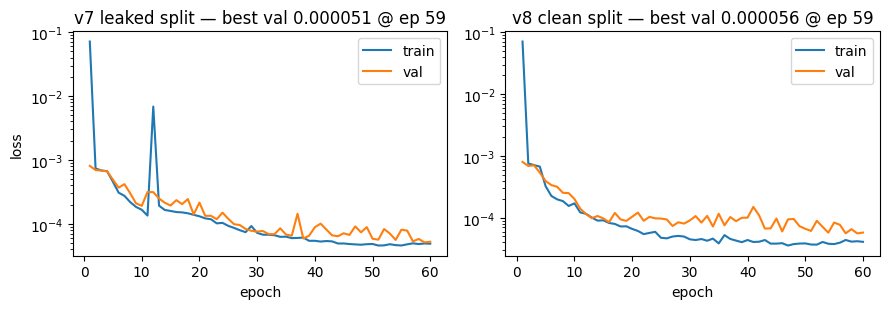

In [3]:
import matplotlib.pyplot as plt

def _extract(history):
    ep  = [h["epoch"] for h in history]
    trs = [h["train"]["total"] for h in history]
    vls = [h["val"]["total"]   for h in history]
    return ep, trs, vls

ep_v7, tr_v7, vl_v7 = _extract(ckpt_v7["history"])
ep_v8, tr_v8, vl_v8 = _extract(ckpt_v8["history"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.2))
a1.plot(ep_v7, tr_v7, label="train")
a1.plot(ep_v7, vl_v7, label="val")
a1.set_title(f"v7 leaked split — best val {min(vl_v7):.6f} @ ep {vl_v7.index(min(vl_v7))+1}")
a1.set_yscale("log"); a1.set_xlabel("epoch"); a1.set_ylabel("loss"); a1.legend()
a2.plot(ep_v8, tr_v8, label="train")
a2.plot(ep_v8, vl_v8, label="val")
a2.set_title(f"v8 clean split — best val {min(vl_v8):.6f} @ ep {vl_v8.index(min(vl_v8))+1}")
a2.set_yscale("log"); a2.set_xlabel("epoch"); a2.legend()
fig.tight_layout()
out_curve = PROJ / "outputs" / "results" / "v8_clean_train_curve.pdf"
out_curve.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_curve, dpi=200, bbox_inches="tight")
print(f"wrote {out_curve}")
plt.show()


## 4. Re-evaluate BOTH models on the same held-out real cells

Same held-out cells as v7.1 (CALB_0029, EVE_0003, REPT_0028) with the
same DCIR inputs as in the current pipeline. This isolates the effect of
the split repair from any other confound.

In [4]:
from phase3_v7_validate import load_v7_operator, forecast_v7

def _eval_model_on_heldout(ckpt_path):
    model, _ = load_v7_operator(ckpt_path)
    out = {}
    for cid, mk in [("0029", "CALB"), ("0003", "EVE"), ("0028", "REPT")]:
        r = forecast_v7(model, cid, mk, K=50, forecast_len=500)
        out[f"{mk}_{cid}"] = float(r["rmse_pp_covered"])
    return out

v7_heldout = _eval_model_on_heldout(V7_CKPT)
v8_heldout = _eval_model_on_heldout(V8_CKPT)
print("v7 leaked heldout RMSE (pp):", v7_heldout)
print("v8 clean  heldout RMSE (pp):", v8_heldout)


v7 leaked heldout RMSE (pp): {'CALB_0029': 0.9573578834533691, 'EVE_0003': 0.7941653728485107, 'REPT_0028': 0.46620625257492065}
v8 clean  heldout RMSE (pp): {'CALB_0029': 1.0593750476837158, 'EVE_0003': 0.840880274772644, 'REPT_0028': 0.5114962458610535}


## 5. Leaked vs clean comparison table

In [5]:
def _last_test(ckpt):
    return ckpt.get("test", {}).get("total")

table = {
    "Metric": [
        "Best validation loss",
        "Best epoch",
        "Synthetic test loss",
        "CALB_0029 held-out RMSE (pp)",
        "EVE_0003 held-out RMSE (pp)",
        "REPT_0028 held-out RMSE (pp)",
        "Mean held-out RMSE (pp)",
    ],
    "v7 leaked split": [
        min(vl_v7),
        int(vl_v7.index(min(vl_v7)) + 1),
        _last_test(ckpt_v7),
        v7_heldout["CALB_0029"],
        v7_heldout["EVE_0003"],
        v7_heldout["REPT_0028"],
        float(np.mean(list(v7_heldout.values()))),
    ],
    "v8 grouped split": [
        min(vl_v8),
        int(vl_v8.index(min(vl_v8)) + 1),
        _last_test(ckpt_v8),
        v8_heldout["CALB_0029"],
        v8_heldout["EVE_0003"],
        v8_heldout["REPT_0028"],
        float(np.mean(list(v8_heldout.values()))),
    ],
}
cmp_df = pd.DataFrame(table)
cmp_out = PROJ / "outputs" / "results" / "v8_clean_val_test_rmse.json"
cmp_df.to_json(cmp_out, orient="records", indent=2)
print(f"wrote {cmp_out}")
cmp_df


wrote /home/hj/Desktop/PINNs/outputs/results/v8_clean_val_test_rmse.json


,Metric,v7 leaked split,v8 grouped split
0,Best validation loss,0.000051,0.000056
1,Best epoch,59.000000,59.000000
2,Synthetic test loss,NaN,0.000054
3,CALB_0029 held-out RMSE (pp),0.957358,1.059375
4,EVE_0003 held-out RMSE (pp),0.794165,0.840880
5,REPT_0028 held-out RMSE (pp),0.466206,0.511496
6,Mean held-out RMSE (pp),0.739243,0.803917


## 6. Verdict marker

- [ ] **PASS** — acceptance criterion fully met.
- [ ] **PASS WITH LIMITATIONS**
- [ ] **FAIL — BLOCKS DOWNSTREAM CLAIM**

**Overall verdict**: `pending — populate after running the comparison`

**Result artifact(s) written**:
- `outputs/models/pinn_phase3_v8_clean.pt`
- `outputs/results/v8_clean_train_curve.pdf`
- `outputs/results/v8_clean_val_test_rmse.json`

**Notes** (fill in after execution):
- v7 val loss vs v8 val loss:
- v7 best epoch vs v8 best epoch:
- v7 held-out mean vs v8 held-out mean:
- Interpretation: does the clean split narrow, widen, or preserve the held-out RMSE?
